### **OpenCLIP con Docker, una GPU y plantillas SLURM**

Este cuaderno es el **centro didáctico** del proyecto, no toda la lógica del proyecto.

Su función es:

- explicar la lógica experimental,
- inspeccionar el subconjunto real ya incluido,
- correr el baseline preentrenado,
- revisar recuperación y negativos difíciles,
- mostrar cómo se escala a `torchrun` y SLURM,
- y dejar el pipeline automatizado en `scripts/` y `src/`.

#### **Idea principal**
El flujo realista de trabajo es:

1. trabajar primero con un checkpoint preentrenado,
2. extraer embeddings de un subconjunto real,
3. evaluar recuperación cruzada,
4. inspeccionar errores,
5. dejar el fine-tuning CSV como extensión controlada.


In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
from pathlib import Path
import json
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("Ejecuta este cuaderno desde la carpeta Semana4/")

sys.path.append(str(PROJECT_ROOT))

from src.io_utils import load_yaml
from src.dataset_utils import load_metadata
from src.openclip_utils import create_model, encode_image_paths, encode_texts
from src.metrics import summarize_ranking
from src.retrieval import topk_text_to_image, topk_image_to_text, mine_hard_negatives
from src.visualize import show_gallery, show_retrieval_results


#### **1. Cargar configuración local**


In [3]:
cfg = load_yaml(PROJECT_ROOT / "configs/local.yaml")
cfg


{'project': {'name': 'MCC225-Semana4-OpenCLIP', 'root': '.'},
 'data': {'metadata_csv': 'data/bootstrap_flickr30k/metadata.csv',
  'query_csv': 'data/bootstrap_flickr30k/queries.csv',
  'prompt_config': 'data/bootstrap_flickr30k/prompt_config.json'},
 'model': {'model_name': 'ViT-B-32',
  'pretrained': 'laion2b_s34b_b79k',
  'precision': 'amp'},
 'runtime': {'batch_size': 16,
  'num_workers': 2,
  'device': 'cuda_if_available'},
 'outputs': {'embeddings_npz': 'outputs/embeddings/bootstrap_embeddings.npz',
  'retrieval_metrics_json': 'outputs/metrics/retrieval_metrics.json',
  'hard_negatives_csv': 'outputs/metrics/hard_negatives.csv',
  'zeroshot_predictions_csv': 'outputs/metrics/zeroshot_predictions.csv'}}

#### **2. Verificación rápida del entorno**

Este cuaderno está alineado con el flujo Docker del curso.  
Antes de correr experimentos, conviene verificar:

- versión de PyTorch,
- visibilidad de CUDA,
- nombre de GPU,
- disponibilidad de `open_clip`.


In [4]:
!python scripts/00_verify_env.py


Python: 3.11.15 (main, May  8 2026, 20:07:36) [GCC 14.2.0]
Platform: Linux-6.6.87.2-microsoft-standard-WSL2-x86_64-with-glibc2.41
torch.__version__ = 2.4.1+cpu
torch.version.cuda = None
torch.cuda.is_available() = False
torch.cuda.device_count() = 0
open_clip = 2.26.1
datasets = 2.21.0


#### **3. Inspección del subconjunto real ya incluido**

En esta etapa se trabaja con un **bootstrap sample real de Flickr30k** ya materializado dentro del proyecto. Su función no es reemplazar al dataset completo, sino actuar como una muestra controlada para verificar el flujo experimental antes de escalar a un subconjunto mayor.

El valor de este bootstrap está en que permite observar el comportamiento de un modelo contrastivo sobre pares imagen-texto reales. Cada imagen tiene una descripción asociada y el sistema debe proyectar ambas modalidades a un espacio vectorial común, donde las correspondencias correctas deberían quedar cercanas y las incorrectas deberían quedar más alejadas.

Desde una perspectiva avanzada, esta inspección permite discutir tres aspectos centrales del aprendizaje multimodal:

1. **Alineamiento semántico entre modalidades**  
   El modelo no compara píxeles con palabras de forma directa. Compara representaciones latentes aprendidas. Por eso, una recuperación correcta indica que el embedding visual y el embedding textual capturan información semántica compatible.

2. **Limitaciones de una muestra pequeña**  
   El bootstrap permite validar código, rutas, dependencias y métricas, pero no permite sacar conclusiones estadísticamente fuertes sobre desempeño general. Sus resultados deben interpretarse como diagnóstico funcional, no como evaluación final del modelo.

3. **Aparición de negativos difíciles**  
   Algunos errores no son aleatorios. Una **caption** incorrecta puede ser muy similar a la imagen si comparte objetos, acciones, contexto visual o composición. Estos casos son útiles porque muestran dónde el modelo confunde correlaciones superficiales con correspondencias semánticas más precisas.

Este subconjunto sirve entonces para:

- inspeccionar ejemplos reales de imagen y caption,
- ejecutar una prueba rápida de recuperación,
- verificar que los embeddings se construyen correctamente,
- analizar errores cualitativos,
- estudiar negativos difíciles,
- demostrar el pipeline sin depender de una descarga grande inicial.

La idea metodológica es empezar con una muestra pequeña, controlada y reproducible. Una vez validado el pipeline, se puede pasar a `Vishva007/Flickr-Dataset-1k` para obtener métricas más representativas y analizar el comportamiento del modelo en un escenario menos trivial.


In [5]:
metadata = load_metadata(PROJECT_ROOT / "data/bootstrap_flickr30k/metadata.csv", root=PROJECT_ROOT)
metadata[["image_id", "label", "caption"]]


,image_id,label,caption
0,flickr30k_0000,people_outdoors,Two young guys with shaggy hair look at their ...
1,flickr30k_0001,industrial_workers,Several men in hard hats are operating a giant...
2,flickr30k_0002,child_play,A child in a pink dress is climbing up a set o...
3,flickr30k_0003,maintenance,A man on a ladder cleans a window.
4,flickr30k_0004,cooking,Two men are cooking a meal.
5,flickr30k_0005,performance,A man is fixing the guitar player's costume.


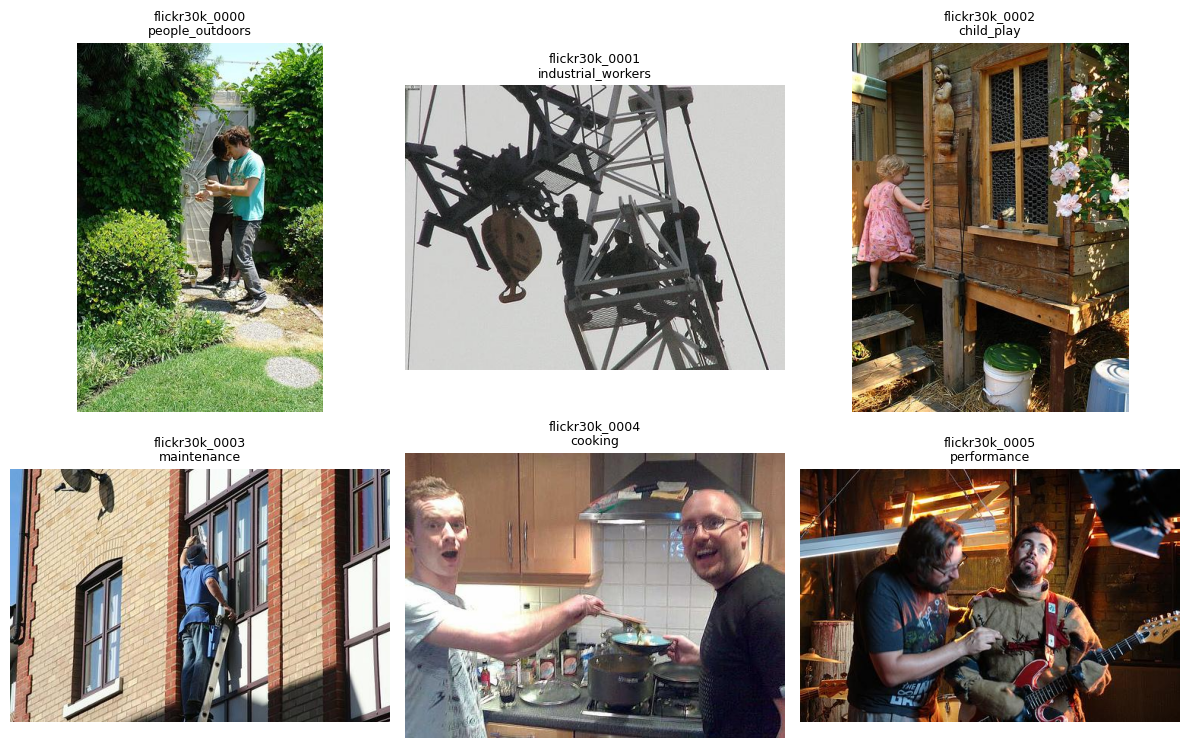

In [6]:
fig = show_gallery(metadata, ncols=3, figsize=(12, 8))
plt.show()


#### **4. Cargar OpenCLIP**

En esta etapa cargamos **OpenCLIP**, una implementación abierta de modelos tipo CLIP entrenados para alinear imágenes y texto en un mismo espacio de representación. La idea central es aprender dos codificadores: uno visual y uno textual. El codificador visual transforma una imagen en un vector y el codificador textual transforma una **caption** o **prompt** en otro vector. Si la imagen y el texto describen el mismo contenido, ambos vectores deberían quedar cercanos según una medida como similitud coseno.

Para este laboratorio usamos un baseline sólido y razonable para una sola GPU:

- `ViT-B-32`
- `laion2b_s34b_b79k`

`ViT-B-32` indica que el encoder visual está basado en un **Vision Transformer** base con parches de tamaño 32. Esto ofrece un equilibrio adecuado entre costo computacional y calidad de representación. No es el modelo más grande, pero sí es suficientemente expresivo para estudiar recuperación imagen-texto en una sesión de laboratorio.

`laion2b_s34b_b79k` indica que el checkpoint fue preentrenado con datos imagen-texto a gran escala. Esto permite usar el modelo como extractor general de representaciones sin necesidad de entrenarlo desde cero. 

En el contexto de semana 4, esto es importante porque el objetivo no es optimizar un modelo fundacional, sino comprender cómo funciona el alineamiento contrastivo y cómo se evalúa la recuperación cruzada.

Desde una perspectiva avanzada, OpenCLIP permite estudiar tres ideas clave:

1. **Representación compartida entre modalidades**  
   Imagen y texto se proyectan al mismo espacio vectorial. Esto hace posible comparar directamente una imagen con muchas captions o una caption con muchas imágenes.

2. **Aprendizaje contrastivo como criterio de alineamiento**  
   Durante el preentrenamiento, el modelo aprende a acercar pares correctos imagen-texto y alejar pares incorrectos. La recuperación que hacemos en este laboratorio es una consecuencia directa de ese entrenamiento.

3. **Uso de modelos preentrenados como baseline experimental**  
   El checkpoint sirve como línea base reproducible. A partir de él se pueden analizar métricas, errores, negativos difíciles, sensibilidad a prompts y diferencias entre datasets sin modificar todavía los pesos del modelo.

En este proyecto, OpenCLIP se usa para construir embeddings normalizados de imágenes y captions. Luego se calcula una matriz de similitud entre ambas modalidades. Esa matriz permite evaluar recuperación imagen->texto y texto->imagen, además de identificar negativos difíciles donde el modelo asigna alta similitud a pares incorrectos pero semánticamente parecidos.

La elección de `ViT-B-32` con `laion2b_s34b_b79k` es apropiada para esta semana porque permite trabajar con un modelo real, abierto y reproducible, manteniendo el costo computacional dentro de lo razonable para una práctica en Docker con una sola GPU.


In [7]:
model_name = cfg["model"]["model_name"]
pretrained = cfg["model"]["pretrained"]

model, preprocess, tokenizer, device = create_model(model_name, pretrained)
print("device =", device)
print("model_name =", model_name)
print("pretrained =", pretrained)


open_clip_pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

device = cpu
model_name = ViT-B-32
pretrained = laion2b_s34b_b79k


#### **5. Extraer embeddings del subconjunto bootstrap**


In [8]:
image_features = encode_image_paths(
    model,
    preprocess,
    metadata["filepath"].tolist(),
    device=device,
    batch_size=cfg["runtime"]["batch_size"],
)

text_features = encode_texts(
    model,
    tokenizer,
    metadata["caption"].tolist(),
    device=device,
    batch_size=max(cfg["runtime"]["batch_size"], 32),
)

image_features.shape, text_features.shape


((6, 512), (6, 512))

#### **6. Matriz de similitud y métricas de retrieval**

Como el bootstrap tiene pares alineados `(imagen_i, caption_i)`, la diagonal representa el match correcto.


In [9]:
sim = image_features @ text_features.T
metrics_i2t = summarize_ranking(sim)
metrics_t2i = summarize_ranking(sim.T)

pd.DataFrame([
    {"direction": "image_to_text", **{k: v for k, v in metrics_i2t.items() if k != "Ranks"}},
    {"direction": "text_to_image", **{k: v for k, v in metrics_t2i.items() if k != "Ranks"}},
])


,direction,R@1,R@5,R@10,MRR,MeanRank,MedianRank
0,image_to_text,1.0,1.0,1.0,1.0,1.0,1.0
1,text_to_image,1.0,1.0,1.0,1.0,1.0,1.0


#### **7. Ejemplos de recuperación cruzada**


In [10]:
query = "two men cooking in a kitchen"
query_feature = encode_texts(model, tokenizer, [query], device=device)
results = topk_text_to_image(query_feature, image_features, metadata, k=4)
results


,rank,image_id,filepath,caption,label,score
0,1,flickr30k_0004,/workspace/Semana4/Proyecto/data/bootstrap_fli...,Two men are cooking a meal.,cooking,0.332115
1,2,flickr30k_0000,/workspace/Semana4/Proyecto/data/bootstrap_fli...,Two young guys with shaggy hair look at their ...,people_outdoors,0.194002
2,3,flickr30k_0005,/workspace/Semana4/Proyecto/data/bootstrap_fli...,A man is fixing the guitar player's costume.,performance,0.183406
3,4,flickr30k_0003,/workspace/Semana4/Proyecto/data/bootstrap_fli...,A man on a ladder cleans a window.,maintenance,0.102121


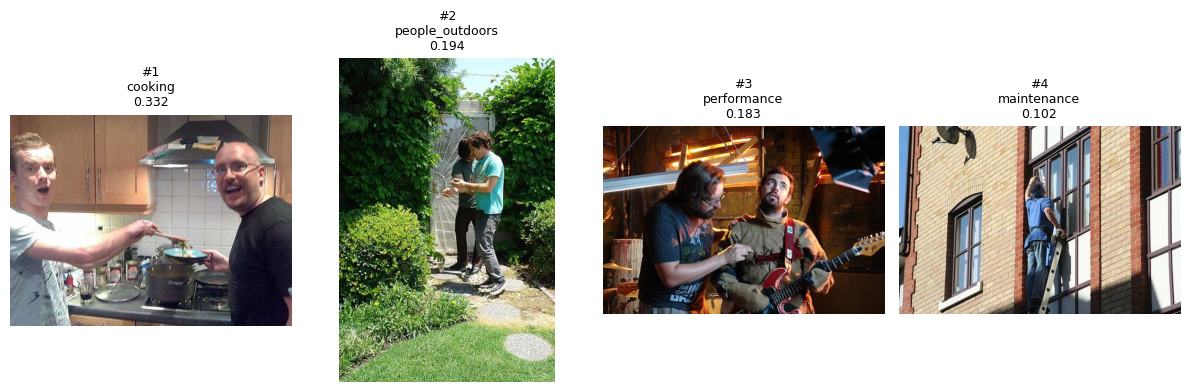

In [11]:
fig = show_retrieval_results(results, figsize=(12, 4))
plt.show()


In [12]:
img_idx = 3
image_result = topk_image_to_text(image_features[img_idx:img_idx+1], text_features, metadata, k=4)
image_result


,rank,image_id,caption_id,caption,label,score
0,1,flickr30k_0003,,A man on a ladder cleans a window.,maintenance,0.353170
1,2,flickr30k_0001,,Several men in hard hats are operating a giant...,industrial_workers,0.205685
2,3,flickr30k_0005,,A man is fixing the guitar player's costume.,performance,0.147673
3,4,flickr30k_0000,,Two young guys with shaggy hair look at their ...,people_outdoors,0.111296


#### **8. Negativos difíciles**

Esta parte importa tanto como la métrica agregada. Los negativos difíciles muestran pares incorrectos con score alto y permiten discutir:

- correlaciones espurias,
- ambigüedad semántica,
- similitud superficial,
- límites del embedding compartido.


In [14]:
hard = mine_hard_negatives(sim, metadata, top_n=8)
hard[["image_id", "image_label", "text_label", "score", "negative_caption"]]


,image_id,image_label,text_label,score,negative_caption
0,flickr30k_0000,people_outdoors,performance,0.231371,A man is fixing the guitar player's costume.
1,flickr30k_0005,performance,people_outdoors,0.230163,Two young guys with shaggy hair look at their ...
2,flickr30k_0000,people_outdoors,cooking,0.218437,Two men are cooking a meal.
3,flickr30k_0000,people_outdoors,maintenance,0.216536,A man on a ladder cleans a window.
4,flickr30k_0003,maintenance,industrial_workers,0.205685,Several men in hard hats are operating a giant...
5,flickr30k_0001,industrial_workers,maintenance,0.186456,A man on a ladder cleans a window.
6,flickr30k_0005,performance,cooking,0.180255,Two men are cooking a meal.
7,flickr30k_0004,cooking,people_outdoors,0.175041,Two young guys with shaggy hair look at their ...


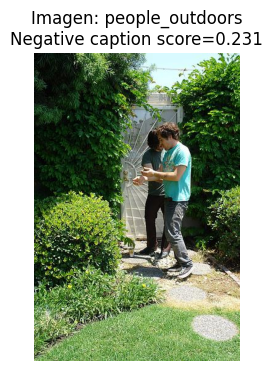

Caption correcto:
Two young guys with shaggy hair look at their hands while hanging out in the yard.

Negativo dificil:
A man is fixing the guitar player's costume.


In [15]:
hard = mine_hard_negatives(sim, metadata, top_n=8)
hard[["image_id", "image_label", "text_label", "score", "negative_caption"]]
row = hard.iloc[0]
img = Image.open(row["image_filepath"]).convert("RGB")
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title(f'Imagen: {row["image_label"]}\nNegative caption score={row["score"]:.3f}')
plt.axis("off")
plt.show()

print("Caption correcto:")
print(row["image_caption"])
print()
print("Negativo dificil:")
print(row["negative_caption"])


#### **9. Zero-shot como extensión**

El proyecto incluye una extensión **zero-shot** mínima para mostrar que un modelo contrastivo imagen-texto sirve también para clasificación sin entrenamiento adicional sobre las clases del laboratorio.

En este contexto, **zero-shot** significa que el modelo no se ajusta con ejemplos etiquetados del bootstrap. En lugar de entrenar un clasificador nuevo, se construyen prompts textuales que representan cada clase posible, por ejemplo una frase del tipo "a photo of a dog" o "a photo of a person riding a bike". Luego, cada imagen se compara contra los embeddings de esos prompts y se asigna la clase cuyo texto queda más cerca en el espacio compartido.

La columna `label` del bootstrap es pequeña y curada solo para demostración. No debe interpretarse como una taxonomía completa de Flickr30k ni como una evaluación robusta de clasificación. Su objetivo es permitir una prueba controlada del mecanismo zero-shot y conectar el laboratorio de recuperación con una tarea de decisión supervisada aparente, pero sin entrenamiento supervisado.

Desde una perspectiva de posgrado, esta extensión permite discutir cuatro ideas importantes:

1. **Clasificación como recuperación texto-imagen**  
   El modelo no aprende una capa clasificadora específica. La predicción surge de comparar la imagen contra descripciones textuales de clases. Por eso, la calidad del resultado depende tanto del encoder visual como de la formulación de los prompts.

2. **Sensibilidad al prompt**  
   Cambiar la redacción de una clase puede modificar la predicción. Por ejemplo, "a photo of a dog", "a dog in an outdoor scene" y "an image of a pet" no necesariamente producen el mismo embedding textual. Esto permite introducir el concepto de prompt engineering en modelos multimodales.

3. **Diferencia entre etiqueta y descripción visual**  
   Una etiqueta corta puede ser demasiado pobre para capturar la escena completa. Si una imagen contiene una persona, una bicicleta, una calle y movimiento, una sola clase puede ocultar ambigüedad semántica. El zero-shot funciona mejor cuando los prompts describen visualmente lo que el modelo puede reconocer.

4. **Evaluación limitada por el diseño del bootstrap**  
   Como el conjunto es pequeño, las métricas zero-shot deben leerse como una demostración funcional. No permiten afirmar que el modelo generaliza bien a una población amplia de imágenes. Para una evaluación más seria se necesitarían más clases, más ejemplos por clase, prompts alternativos y análisis de confusión.

En este proyecto, el zero-shot debe entenderse como una extensión conceptual del alineamiento contrastivo. Primero se aprende un espacio común imagen-texto. Luego se usa ese espacio para recuperar captions, comparar prompts y asignar clases sin reentrenar el modelo.



In [16]:
!python scripts/02_build_embeddings.py   --metadata-csv data/bootstrap_flickr30k/metadata.csv   --model-name ViT-B-32   --pretrained laion2b_s34b_b79k   --batch-size 16   --output outputs/embeddings/bootstrap_embeddings.npz


Embeddings guardados en outputs/embeddings/bootstrap_embeddings.npz
Text metadata guardado en outputs/embeddings/bootstrap_embeddings.text_metadata.csv
Imágenes: 6 | Textos: 6 | caption_mode=first


In [17]:
!python scripts/04_eval_zeroshot.py   --embeddings outputs/embeddings/bootstrap_embeddings.npz   --metadata-csv data/bootstrap_flickr30k/metadata.csv   --prompt-config data/bootstrap_flickr30k/prompt_config.json   --output-csv outputs/metrics/zeroshot_predictions.csv


Accuracy: 0.8333333333333334
Guardados: outputs/metrics/zeroshot_predictions.csv


In [18]:
pd.read_csv(PROJECT_ROOT / "outputs/metrics/zeroshot_predictions.csv")


,image_id,filepath,caption,label,pred_label,is_correct,prompt_template_used
0,flickr30k_0000,/workspace/Semana4/Proyecto/data/bootstrap_fli...,Two young guys with shaggy hair look at their ...,people_outdoors,maintenance,False,a photo of {}
1,flickr30k_0001,/workspace/Semana4/Proyecto/data/bootstrap_fli...,Several men in hard hats are operating a giant...,industrial_workers,industrial_workers,True,a photo of {}
2,flickr30k_0002,/workspace/Semana4/Proyecto/data/bootstrap_fli...,A child in a pink dress is climbing up a set o...,child_play,child_play,True,a photo of {}
3,flickr30k_0003,/workspace/Semana4/Proyecto/data/bootstrap_fli...,A man on a ladder cleans a window.,maintenance,maintenance,True,a photo of {}
4,flickr30k_0004,/workspace/Semana4/Proyecto/data/bootstrap_fli...,Two men are cooking a meal.,cooking,cooking,True,a photo of {}
5,flickr30k_0005,/workspace/Semana4/Proyecto/data/bootstrap_fli...,A man is fixing the guitar player's costume.,performance,performance,True,a photo of {}


#### **10. Pipeline reproducible fuera del notebook**

La idea correcta no es dejar todo dentro del notebook.

El proyecto ya trae pipeline reproducible:

- `scripts/run_local_pipeline.sh`
- `scripts/10_train_openclip_csv_local.sh`
- `scripts/11_train_openclip_csv_torchrun.sh`
- `slurm/train_openclip_csv_single_node.sbatch`
- `slurm/train_openclip_csv_multi_node.sbatch`

**Pipeline local completo**
```bash
bash scripts/run_local_pipeline.sh
```

**Fine-tuning CSV local muy corto**
```bash
bash scripts/10_train_openclip_csv_local.sh
```

**Template torchrun**
```bash
bash scripts/11_train_openclip_csv_torchrun.sh
```


#### **11. Descargar un subconjunto mayor y más realista de Flickr30k**

Cuando quieras salir del bootstrap y pasar a algo más serio, ejecuta:


In [ ]:
# Descomenta cuando quieras materializar un subconjunto mayor
# !python scripts/01_prepare_flickr30k_from_hf.py #   --output-root data/processed/flickr1k_hf #   --train-limit 512 #   --val-limit 50 #   --test-limit 50


In [ ]:
!python scripts/01_prepare_flickr30k_from_hf.py \
  --output-root data/processed/flickr1k_hf \
  --train-limit 512 \
  --val-limit 50 \
  --test-limit 50

Después puedes cambiar el CSV de entrada en `scripts/02_build_embeddings.py` y repetir la evaluación.

Eso te deja una progresión clara:

- bootstrap real incluido,
- subconjunto mayor descargado desde HF,
- evaluación reproducible,
- extensión a entrenamiento CSV,
- y plantillas listas para SLURM.


#### **12. Entregables sugeridos**

El estudiante debe entregar un notebook exportado. No se debe crear un archivo Markdown adicional dentro del proyecto.

El informe debe incluir:

1. Comandos ejecutados dentro del contenedor Docker.
2. Evidencia de ejecución del pipeline local con el bootstrap.
3. Evidencia de ejecución del pipeline remoto con `Vishva007/Flickr-Dataset-1k`, si hubo conexión a internet.
4. Tabla comparativa con `R@1`, `R@5`, `R@10` y `MRR`.
5. Análisis comentado de cinco negativos difíciles.
6. Comparación entre `--caption-mode first` y `--caption-mode all`.
7. Una mini ablación experimental.
8. Conclusiones técnicas y limitaciones del modelo.

##### **12.1 Experimentos mínimos**

Ejecutar el pipeline local dentro del contenedor:

```bash
cd /workspace/Semana4/Proyecto
bash scripts/run_local_pipeline.sh
```

Ejecutar el pipeline remoto dentro del contenedor:

```bash
cd /workspace/Semana4/Proyecto
bash scripts/run_hf_flickr1k_pipeline.sh
```

Comparar los resultados generados en:

```text
outputs/metrics/retrieval_metrics.json
outputs/metrics/hard_negatives.csv
outputs/metrics/flickr1k_retrieval_metrics.json
outputs/metrics/flickr1k_hard_negatives.csv
```

##### **12.2 Mini ablación sugerida**

El estudiante debe realizar al menos una de las siguientes variaciones.

**Comparar modos de captions**

Ejecutar una evaluación con una sola caption por imagen:

```bash
python scripts/02_build_embeddings.py \
  --metadata-csv data/processed/flickr1k_hf/all.csv \
  --model-name ViT-B-32 \
  --pretrained laion2b_s34b_b79k \
  --batch-size 32 \
  --caption-mode first \
  --output outputs/embeddings/flickr1k_embeddings_first.npz

python scripts/03_eval_retrieval.py \
  --embeddings outputs/embeddings/flickr1k_embeddings_first.npz \
  --metadata-csv data/processed/flickr1k_hf/all.csv \
  --output-json outputs/metrics/flickr1k_retrieval_metrics_first.json \
  --hard-negatives-csv outputs/metrics/flickr1k_hard_negatives_first.csv \
  --top-n-hard-negatives 20
```

Ejecutar una evaluación con todas las captions por imagen:

```bash
python scripts/02_build_embeddings.py \
  --metadata-csv data/processed/flickr1k_hf/all.csv \
  --model-name ViT-B-32 \
  --pretrained laion2b_s34b_b79k \
  --batch-size 32 \
  --caption-mode all \
  --output outputs/embeddings/flickr1k_embeddings_all.npz

python scripts/03_eval_retrieval.py \
  --embeddings outputs/embeddings/flickr1k_embeddings_all.npz \
  --metadata-csv data/processed/flickr1k_hf/all.csv \
  --output-json outputs/metrics/flickr1k_retrieval_metrics_all.json \
  --hard-negatives-csv outputs/metrics/flickr1k_hard_negatives_all.csv \
  --top-n-hard-negatives 20
```

**Cambiar el tamaño de batch**

Comparar al menos dos valores:

```bash
--batch-size 16
```

```bash
--batch-size 32
```

Reportar si cambia el tiempo de ejecución, el uso de memoria o la estabilidad del proceso.

**Comparar dos checkpoints de OpenCLIP**

Ejemplo base:

```bash
--model-name ViT-B-32
--pretrained laion2b_s34b_b79k
```

Ejemplo alternativo:

```bash
--model-name RN50
--pretrained openai
```

Reportar cuál obtiene mejores métricas y si los errores cualitativos cambian.

##### **12.3 Preguntas para el informe**

Responder brevemente:

1. ¿Qué cambia entre evaluar con una sola caption y evaluar con todas las captions asociadas a la misma imagen?,
2. ¿Qué tipo de errores aparecen en los negativos difíciles?,
3. ¿El modelo confunde objetos, acciones, contexto o relaciones espaciales?,
4. ¿Qué checkpoint obtiene mejores métricas?,
5. ¿Qué limitaciones tiene el bootstrap local frente a Flickr1k?,
6. ¿Qué mejora concreta aplicarías en una siguiente versión del laboratorio?.

##### **12.4 Formato recomendado de entrega**

Toda la documentación del proyecto debe mantenerse en `README.md`.

